In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler , RobustScaler

from sklearn.model_selection import KFold , cross_val_score , TimeSeriesSplit
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

# Part B : Dataset Understanding & Preparation

## Load Dataset

In [2]:
original_data = pd.read_csv('Advanced_Regression_HousePrice.csv')

df = original_data.copy()

df.head(10)

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429
5,200006,2017-09-01,2555,5,3,3.2,25,20.6,0,0,5.63,19298164
6,200007,2017-03-01,2460,6,5,9.0,20,6.9,0,1,4.86,42510938
7,200008,2022-04-01,1880,3,3,6.3,19,10.6,1,1,2.52,19892683
8,200009,2019-02-01,1057,2,3,8.4,13,5.1,0,0,4.93,13052453
9,200010,2017-07-01,1022,4,3,5.3,59,16.5,1,1,4.90,9146947


## Basic Info 

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


In [4]:
df.shape

(3800, 12)

## Dropping Duplicates

In [5]:
df.duplicated().sum()

np.int64(0)

### Therefore, there are no duplicates in this dataset.

## EDA ( Exploratory Data Analysis )

### Univariate Analysis

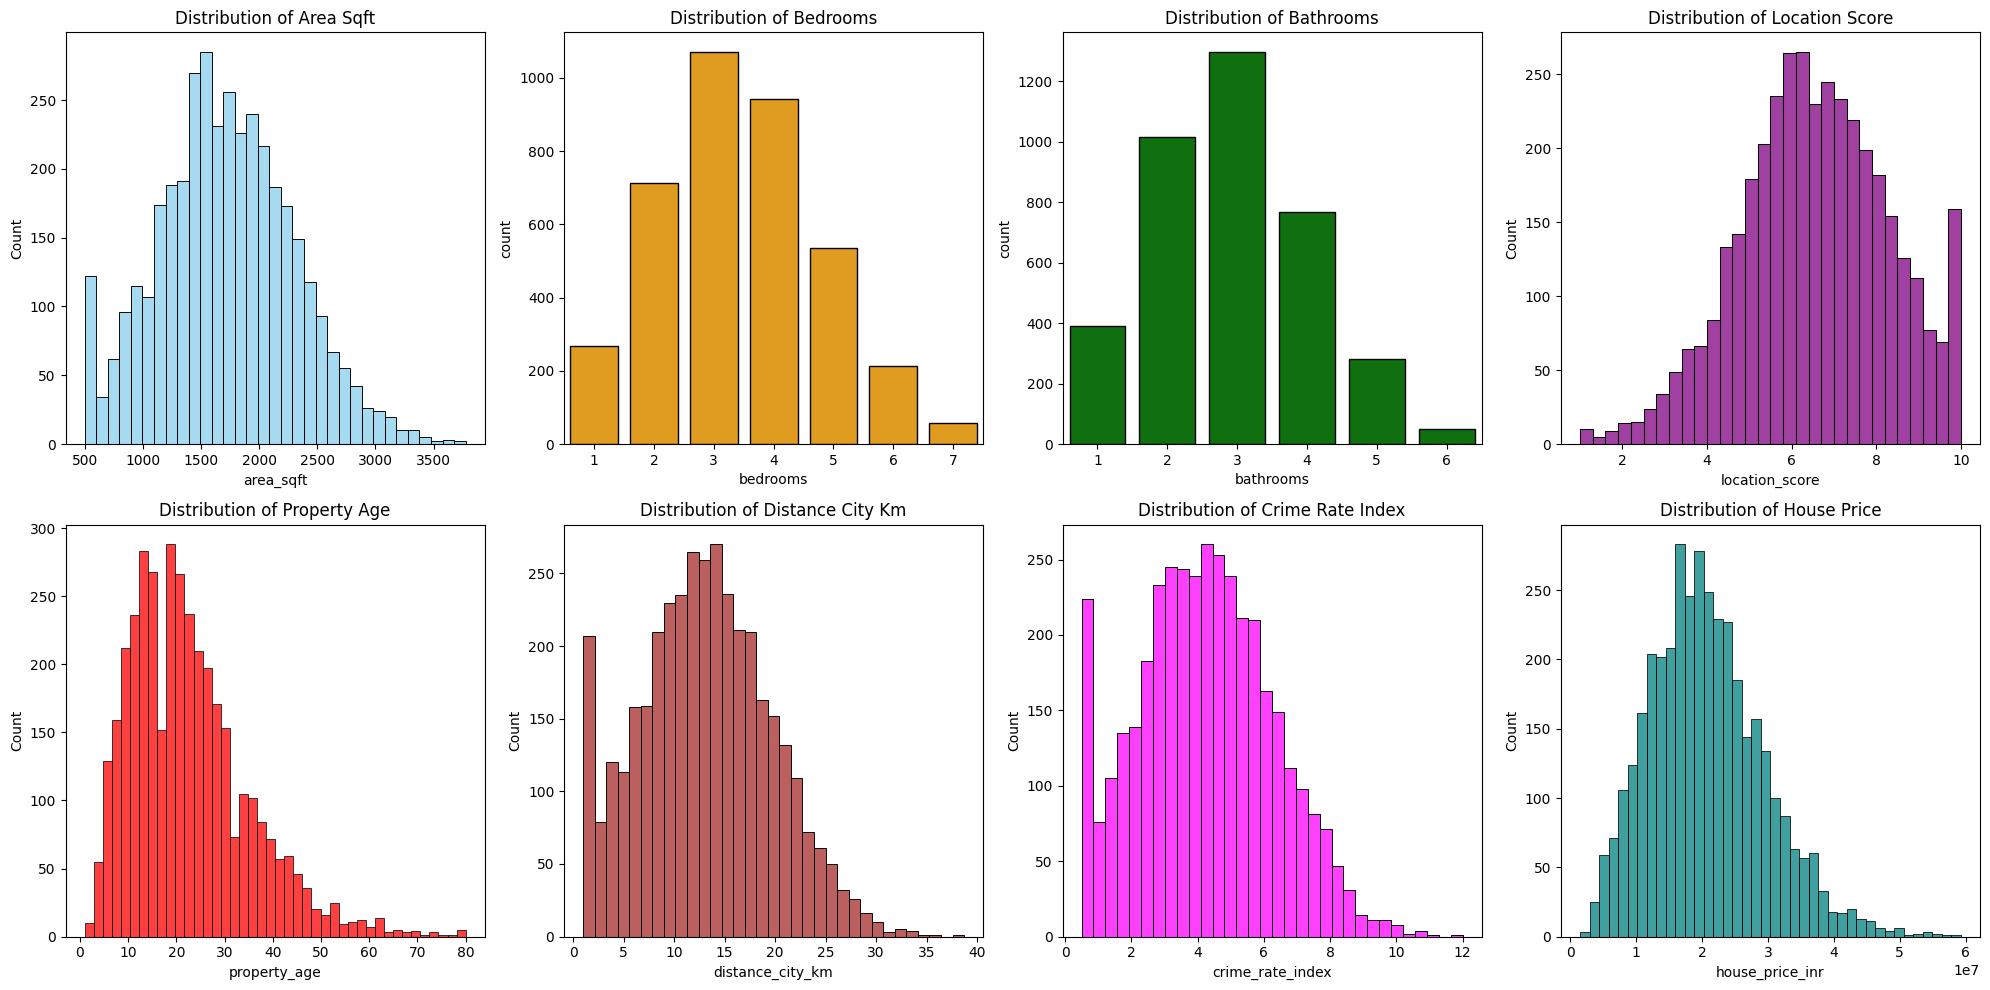

In [6]:
fig , axes = plt.subplots( 2 , 4 , figsize = (20 , 10))

sns.histplot(df['area_sqft'] , color = 'skyblue', edgecolor = 'black' , ax = axes[0,0])

axes[0,0].set_title('Distribution of Area Sqft')

sns.countplot( x = 'bedrooms' , data = df , color = 'orange', edgecolor = 'black' , ax = axes[0,1])

axes[0,1].set_title('Distribution of Bedrooms')

sns.countplot( x = 'bathrooms' , data = df , color = 'green', edgecolor = 'black' , ax = axes[0,2])

axes[0,2].set_title('Distribution of Bathrooms')

sns.histplot(df['location_score'] , color = 'purple', edgecolor = 'black' , ax = axes[0,3])

axes[0,3].set_title('Distribution of Location Score')

sns.histplot(df['property_age'] , color = 'red', edgecolor = 'black' , ax = axes[1,0])

axes[1,0].set_title('Distribution of Property Age')

sns.histplot(df['distance_city_km'] , color = 'brown', edgecolor = 'black' , ax = axes[1,1])

axes[1,1].set_title('Distribution of Distance City Km')

sns.histplot(df['crime_rate_index'], color='magenta' , edgecolor = 'black' , ax=axes[1,2])

axes[1,2].set_title('Distribution of Crime Rate Index')

sns.histplot(df['house_price_inr'], color='teal' , edgecolor = 'black' , ax=axes[1,3])

axes[1,3].set_title('Distribution of House Price')

plt.tight_layout()
plt.show()


### Most numerical features consist Positive Skewness (Right Skewness), suggesting the presence of higher-value observations, while the location score appears Slight Negative Skewness (Left Skewness)

### Bivariate Analysis

In [7]:
df.head(1)

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898


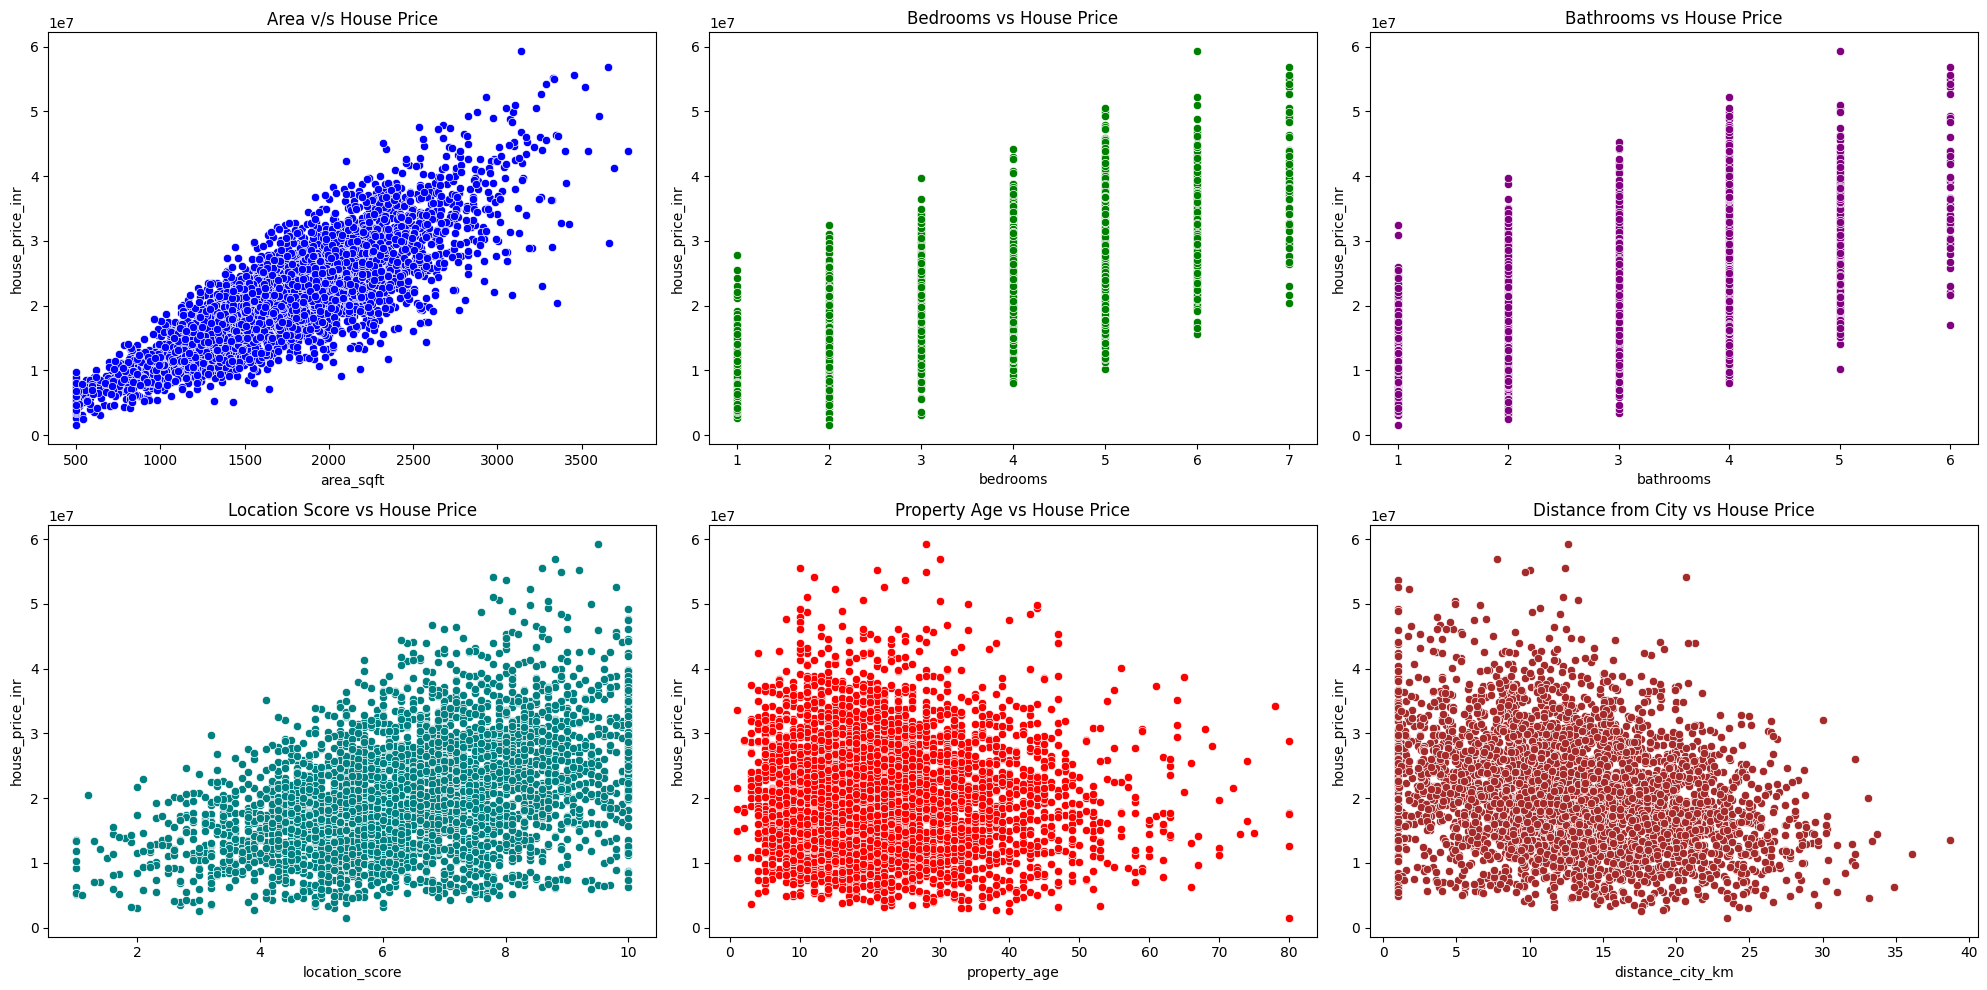

In [8]:
fig , axes = plt.subplots( 2 , 3 , figsize = (20 , 10))

sns.scatterplot(x = 'area_sqft' , y = 'house_price_inr' , data = df , color = 'blue' , ax = axes[0,0])

axes[0,0].set_title('Area v/s House Price')

sns.scatterplot( x = 'bedrooms',y = 'house_price_inr', data = df , color = 'green' , ax = axes[0,1])

axes[0,1].set_title('Bedrooms vs House Price')

sns.scatterplot( x = 'bathrooms', y = 'house_price_inr', data = df, color = 'purple' , ax = axes[0,2])

axes[0,2].set_title('Bathrooms vs House Price')

sns.scatterplot( x = 'location_score', y = 'house_price_inr',  data = df, color = 'teal' , ax = axes[1,0])

axes[1,0].set_title('Location Score vs House Price')

sns.scatterplot( x = 'property_age', y = 'house_price_inr', data = df, color = 'red', ax = axes[1, 1])

axes[1,1].set_title('Property Age vs House Price')

sns.scatterplot( x = 'distance_city_km', y = 'house_price_inr', data = df, color='brown', ax = axes[1, 2])

axes[1,2].set_title('Distance from City vs House Price')

plt.tight_layout()
plt.show()

### According to the scatterplots, Area Sqft, Bedrooms, and Bathrooms show a strong positive relationship with House Price. Location Score shows a moderate positive relationship, while Property Age and Distance from City show a weak to moderate negative relationship with House Price.

### Multivariate Analysis

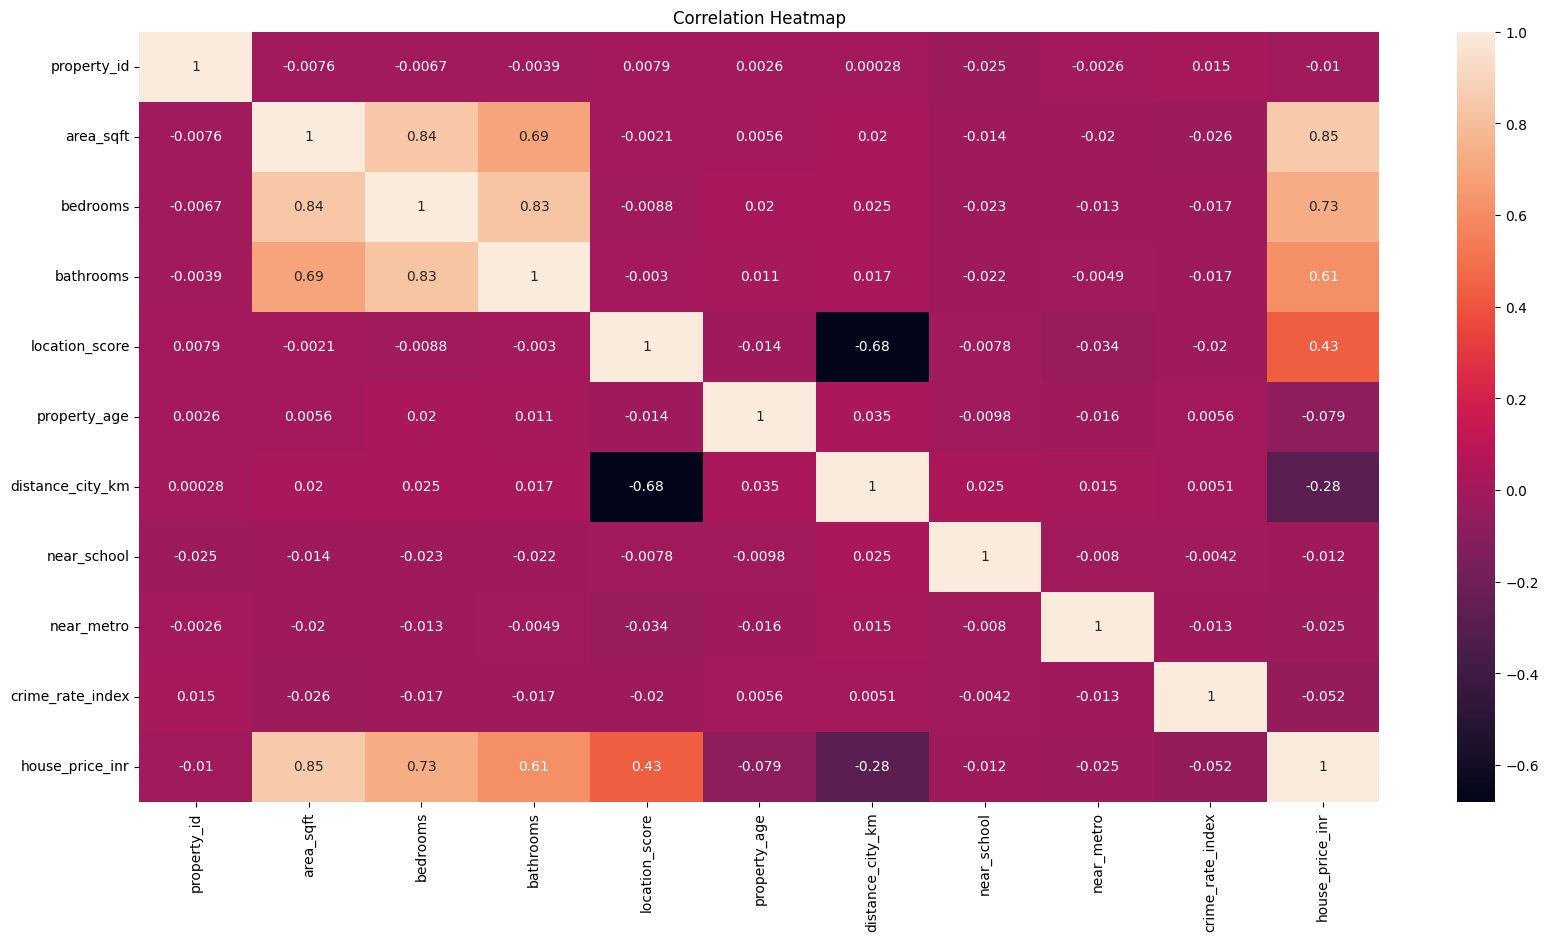

In [9]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Dropping Unnecessary Features

In [10]:
df = df.drop(columns = ['property_id'])

### 'property_id' was dropped because it is a unique identifier and does not contain predictive information.

## Train-Test Split

In [11]:
X = df.drop('house_price_inr' , axis = 1)
y = df['house_price_inr']

In [12]:
X_train , X_test , y_train , y_test = train_test_split( X , y , test_size = 0.2 , random_state=10)

## Identifying Outlier

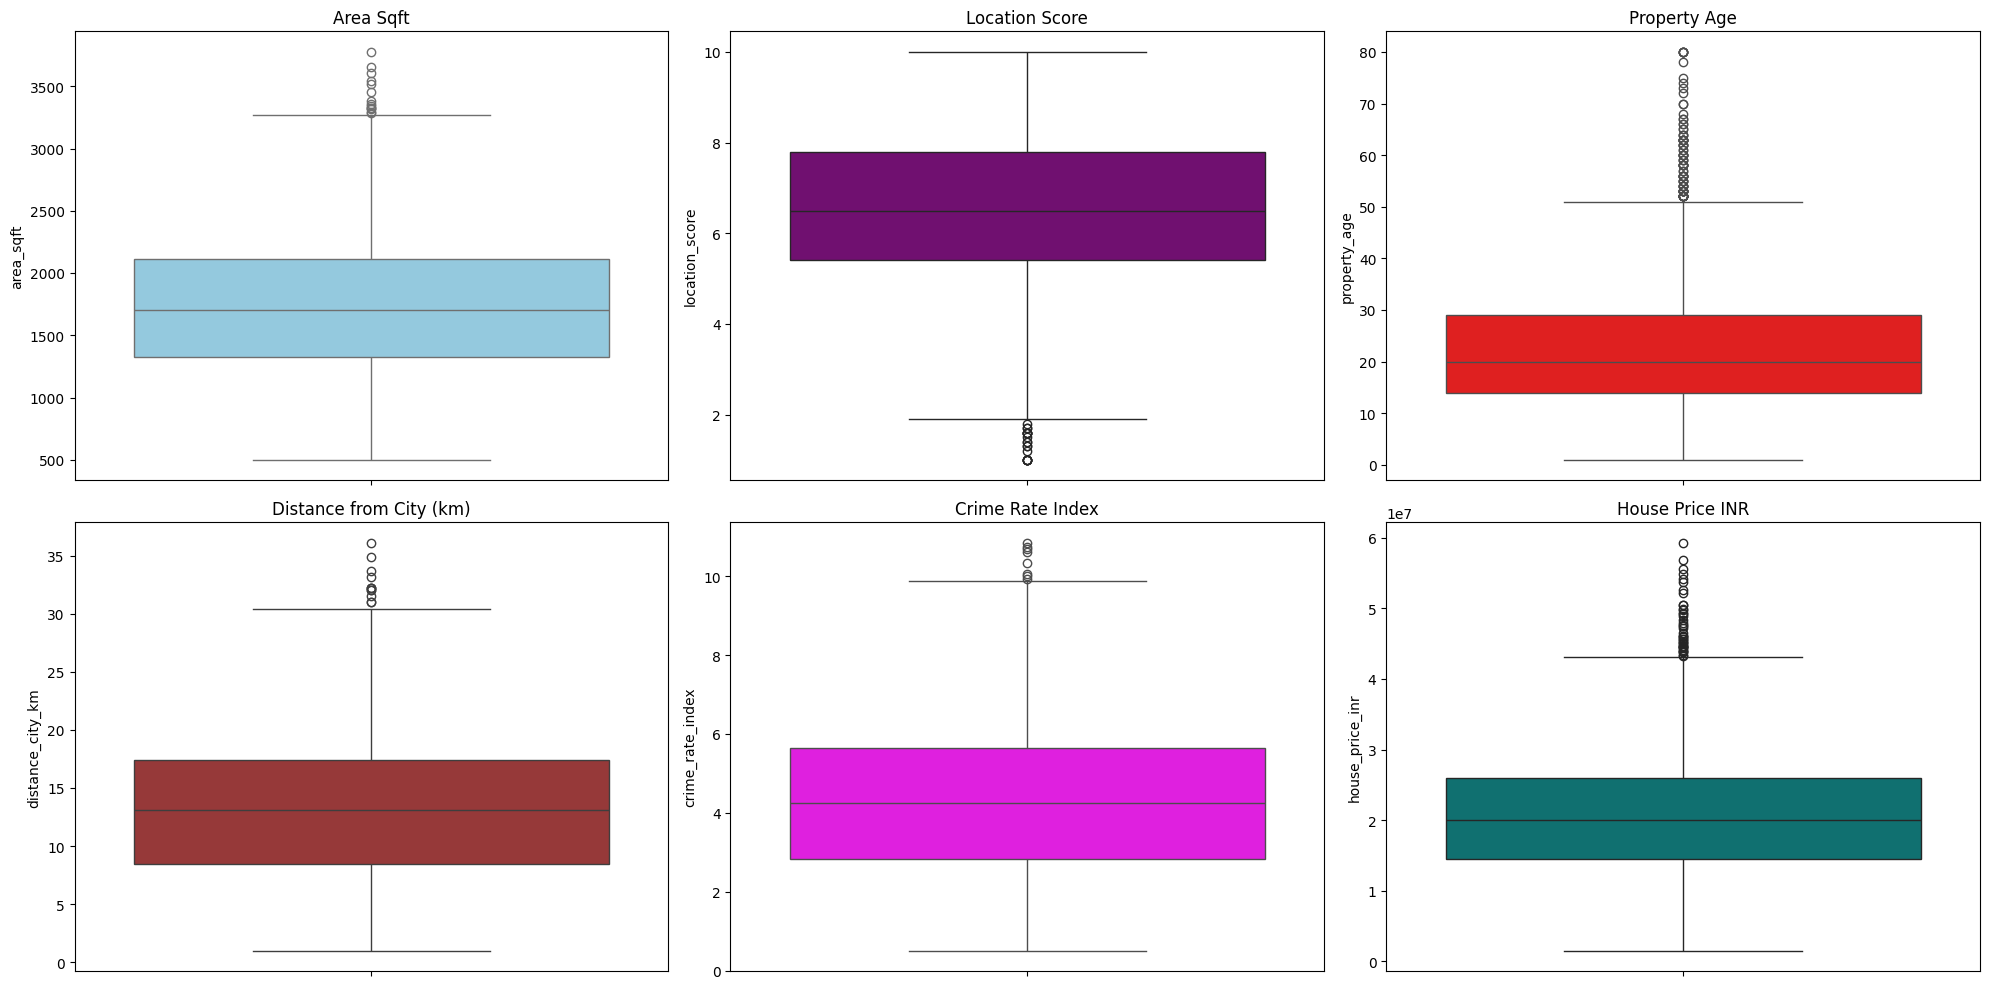

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))


sns.boxplot(y = X_train['area_sqft'], color='skyblue', ax=axes[0,0])

axes[0,0].set_title('Area Sqft')

sns.boxplot(y = X_train['location_score'], color='purple', ax=axes[0,1])

axes[0,1].set_title('Location Score')

sns.boxplot(y = X_train['property_age'], color='red', ax=axes[0,2])

axes[0,2].set_title('Property Age')

sns.boxplot(y = X_train['distance_city_km'], color='brown', ax=axes[1,0])

axes[1,0].set_title('Distance from City (km)')

sns.boxplot(y = X_train['crime_rate_index'], color='magenta', ax=axes[1,1])

axes[1,1].set_title('Crime Rate Index')

sns.boxplot(y = y_train, color='teal', ax=axes[1,2])

axes[1,2].set_title('House Price INR')

plt.tight_layout()

plt.show()

### Boxplots revealed the presence of outliers in some numerical features. However, these observations were retained because they may represent genuine property transactions rather than data entry errors. Since the models achieved satisfactory performance, no outlier treatment was applied.

## Feature Engineering & Transformation

In [14]:
X_train['sale_date'] = pd.to_datetime(X_train['sale_date'])

X_train['sale_year'] = X_train['sale_date'].dt.year
X_train['sale_month'] = X_train['sale_date'].dt.month

X_train.drop('sale_date', axis = 1, inplace = True)

X_test['sale_date'] = pd.to_datetime(X_test['sale_date'])

X_test['sale_year'] = X_test['sale_date'].dt.year
X_test['sale_month'] = X_test['sale_date'].dt.month

X_test.drop('sale_date', axis = 1, inplace = True)

### The sale_date feature was converted to datetime format, and two new features, sale_year and sale_month, were extracted to capture time related trends in house prices. The original sale_date column was then removed.

In [15]:
X_train['premium_location'] = (X_train['location_score'] >= 7.7).astype(int)

X_test['premium_location'] = (X_test['location_score'] >= 7.7).astype(int)

### This feature is created because prices of house differ from the area around house. If Location is good prices are usually high .

## Feature Scaling

In [16]:
robust = RobustScaler()

X_train_Scaled = robust.fit_transform(X_train)

X_test_Scaled = robust.transform(X_test)

### RobustScaler was used because it scales features using the median and interquartile range, making it robust to the influence of outliers present in the dataset. 

# Part C : Regularized Linear Models

## MLR ( Multiple Linear Regression )

In [17]:
MLR_model = LinearRegression()

MLR_model.fit(X_train_Scaled , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred_MLR = MLR_model.predict(X_test_Scaled)

In [19]:
print('MSE (MLR) : ' , mean_squared_error(y_test , y_pred_MLR) )

print('RMSE (MLR) : ' , root_mean_squared_error(y_test , y_pred_MLR) )

print('MAE (MLR) : ' , mean_absolute_error(y_test , y_pred_MLR) )

R2_Score_MLR = r2_score(y_test, y_pred_MLR)

print( "R2 Score (MLR) :", R2_Score_MLR )

n = X_test_Scaled.shape[0]
p = X_test_Scaled.shape[1]

Adjusted_R2 = 1 - ( (1 - R2_Score_MLR) * (n - 1) / (n - p - 1) )

print("Adjusted R2 Score :", Adjusted_R2)

MSE (MLR) :  6525576901499.273
RMSE (MLR) :  2554520.875134763
MAE (MLR) :  1972798.577570508
R2 Score (MLR) : 0.913618640494166
Adjusted R2 Score : 0.9122309881326265


In [20]:
train_r2_MLR = MLR_model.score(X_train_Scaled, y_train)

test_r2_MLR = MLR_model.score(X_test_Scaled, y_test)

print("Train R2 (MLR) :", train_r2_MLR)
print("Test R2 (MLR) :", test_r2_MLR)

Train R2 (MLR) : 0.9190436729762692
Test R2 (MLR) : 0.913618640494166


### MLR ( Multiple Linear Regression ) achieved a test R2 score of 0.913 (91.3%).

### Cross-Validation

In [21]:
cv_MLR = cross_val_score( estimator = MLR_model , X = X_train_Scaled , y = y_train , cv = 5 , scoring ='r2')

print('Cross Validation R2 Scores of MLR : ' , cv_MLR)

print('Average CV R2 Scores of MLR : ' , np.mean(cv_MLR))

Cross Validation R2 Scores of MLR :  [0.91089747 0.92344409 0.92529963 0.91307217 0.91952998]
Average CV R2 Scores of MLR :  0.9184486654226365


### The Multiple Linear Regression model achieved high and consistent R2 scores across K-Fold Cross-Validation, indicating good stability and generalization performance.

## Lasso Regression - L1 ( Regularization Technique)

In [22]:
Lasso_Regression = Lasso(alpha = 1)

Lasso_Regression.fit(X_train_Scaled , y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [23]:
y_pred_Lasso = Lasso_Regression.predict(X_test_Scaled)

In [24]:
print('MSE (Lasso) : ' , mean_squared_error(y_test , y_pred_Lasso) )

print('RMSE (Lasoo) : ' , root_mean_squared_error(y_test , y_pred_Lasso) )

print('MAE (Lasoo) : ' , mean_absolute_error(y_test , y_pred_Lasso) )

R2_score_Lasso = r2_score(y_test, y_pred_Lasso)

print( "Lasso R2 Score:", R2_score_Lasso)

MSE (Lasso) :  6525574056973.904
RMSE (Lasoo) :  2554520.3183717104
MAE (Lasoo) :  1972797.966832019
Lasso R2 Score: 0.91361867814815


In [25]:
train_r2_Lasso = Lasso_Regression.score(X_train_Scaled, y_train)

test_r2_Lasso = Lasso_Regression.score(X_test_Scaled, y_test)

print("Train R2 (Lasoo) : ", train_r2_Lasso)
print("Test R2 (Lasoo) : ", test_r2_Lasso)

Train R2 (Lasoo) :  0.91904367297565
Test R2 (Lasoo) :  0.91361867814815


In [26]:
Lasso_coef_df = pd.DataFrame({
    'Feature' :  X_train.columns,
    'Coefficients ' : Lasso_Regression.coef_
})

Lasso_coef_df

,Feature,Coefficients
0,area_sqft,9.399889e+06
1,bedrooms,3.875377e+05
2,bathrooms,5.064405e+05
3,location_score,5.176732e+06
4,property_age,-8.381021e+05
5,distance_city_km,-9.579040e+04
6,near_school,-8.671533e+03
7,near_metro,1.227069e+05
8,crime_rate_index,-2.478747e+05
9,sale_year,5.436056e+05


### Cross-Validation

In [27]:
cv_Lasso = cross_val_score( estimator = Lasso_Regression , X = X_train_Scaled , y = y_train , cv = 5 , scoring ='r2')

print('Cross Validation R2 Scores of Lasso : ' , cv_Lasso)

print('Average CV R2 Scores of Lasso : ' , np.mean(cv_Lasso))

Cross Validation R2 Scores of Lasso :  [0.91089745 0.9234441  0.92529963 0.91307218 0.91953   ]
Average CV R2 Scores of Lasso :  0.9184486726581136


## Ridge Regression - L2 ( Regularization Technique )

In [28]:
Ridge_Regression = Ridge(alpha = 1)

Ridge_Regression.fit(X_train_Scaled , y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [29]:
y_pred_Ridge = Ridge_Regression.predict(X_test_Scaled)

In [30]:
print('MSE (Ridge) : ' , mean_squared_error(y_test , y_pred_Ridge) )

print('RMSE (Ridge) : ' , root_mean_squared_error(y_test , y_pred_Ridge) )

print('MAE (Ridge) : ' , mean_absolute_error(y_test , y_pred_Ridge) )

R2_score_Ridge = r2_score(y_test, y_pred_Ridge)

print( "Ridge R2 Score:", R2_score_Ridge)

MSE (Ridge) :  6524169191845.512
RMSE (Ridge) :  2554245.3272631257
MAE (Ridge) :  1972172.5917850526
Ridge R2 Score: 0.9136372748425947


In [31]:
train_r2_Ridge = Ridge_Regression.score(X_train_Scaled, y_train)

test_r2_Ridge = Ridge_Regression.score(X_test_Scaled, y_test)

print("Train R2 (Ridge) :", train_r2_Ridge)
print("Test R2 (Ridge) :", test_r2_Ridge)

Train R2 (Ridge) : 0.9190427336245715
Test R2 (Ridge) : 0.9136372748425947


In [32]:
Ridge_coef_df = pd.DataFrame({
    'Feature' : X_train.columns,
    'Coefficients' : Ridge_Regression.coef_
})

Ridge_coef_df

,Feature,Coefficients
0,area_sqft,9.381822e+06
1,bedrooms,4.047746e+05
2,bathrooms,5.051564e+05
3,location_score,5.166780e+06
4,property_age,-8.377049e+05
5,distance_city_km,-9.953492e+04
6,near_school,-8.344612e+03
7,near_metro,1.218921e+05
8,crime_rate_index,-2.480498e+05
9,sale_year,5.431131e+05


### Cross-Validation

In [33]:
cv_Ridge = cross_val_score( estimator = Ridge_Regression , X = X_train_Scaled , y = y_train , cv = 5 , scoring ='r2')

print('Cross Validation R2 Scores of Ridge : ' , cv_Ridge)

print('Average CV R2 Scores of Ridge : ' , np.mean(cv_Ridge))

Cross Validation R2 Scores of Ridge :  [0.91086365 0.92342691 0.92533103 0.91304762 0.91957961]
Average CV R2 Scores of Ridge :  0.9184497649770395


## Comparison ( MLR v/s Lasso v/s Ridge)

In [34]:
Comparison_1 = pd.DataFrame({
    'Model' : ['Multiple Linear Regression' , 'Lasso Regression' , 'Ridge Regression'],
    'Train R2 ' : [train_r2_MLR , train_r2_Lasso , train_r2_Ridge],
    'Test R2 ' : [test_r2_MLR , test_r2_Lasso , test_r2_Ridge],
    'Average of CV ' : [np.mean(cv_MLR) , np.mean(cv_Lasso) , np.mean(cv_Ridge)],
})

Comparison_1

,Model,Train R2,Test R2,Average of CV
0,Multiple Linear Regression,0.919044,0.913619,0.918449
1,Lasso Regression,0.919044,0.913619,0.918449
2,Ridge Regression,0.919043,0.913637,0.918450


### Ridge Regression produced similar results to Multiple Linear Regression and Lasso Regression because the dataset did not contain many irrelevant features, and the MLR model already provided strong generalization performance. Therefore, the regularization effect of Lasso and Ridge had minimal impact on the overall model performance.

### The performance of Multiple Linear Regression, Ridge Regression, and Lasso Regression remained consistent across both StandardScaler and RobustScaler. This indicates that the outliers present in the dataset did not significantly influence model performance.

### Ridge and Lasso Regression produced very similar coefficient values, indicating that regularization had minimal impact on the model. Lasso did not reduce any coefficients to zero, suggesting that all features contributed to house price prediction.

# Part D : Tree-Based Regression Models

## Decision Tree Regressor

In [35]:
DTR_model = DecisionTreeRegressor(max_depth = 5 , min_samples_leaf = 5 , random_state=10)

DTR_model.fit(X_train , y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",10
,"max_leaf

In [36]:
y_pred_DTR = DTR_model.predict(X_test)

In [37]:
print('MSE (DTR) : ' , mean_squared_error(y_test , y_pred_DTR))

print('RMSE (DTR) : ' , root_mean_squared_error(y_test , y_pred_DTR))

print('MAE (DTR) : ' , mean_absolute_error(y_test , y_pred_DTR))

R2_Score_DTR = r2_score(y_test, y_pred_DTR)

print( "R2 Score (DTR) : ", R2_Score_DTR )

MSE (DTR) :  8966483643378.96
RMSE (DTR) :  2994408.730180127
MAE (DTR) :  2245475.5148436567
R2 Score (DTR) :  0.8813074983571267


In [38]:
train_r2_DTR = DTR_model.score(X_train, y_train)

test_r2_DTR = DTR_model.score(X_test, y_test)

print("Train R2 DTR : ", train_r2_DTR)
print("Test R2 DTR : ", test_r2_DTR)

Train R2 DTR :  0.8992029656803847
Test R2 DTR :  0.8813074983571267


### DTR ( Decision Tree Regressor ) achieved  a test R2 score of 0.881 (88%) .

### Cross-Validation

In [39]:
k_fold_dtr = KFold( n_splits = 5 , shuffle = True , random_state = 10)

cvs_dtr = cross_val_score( estimator = DTR_model , X = X_train , y = y_train , cv = k_fold_dtr , scoring = 'r2')

print("K-Fold CV Scores of DTR :", cvs_dtr)

print("Average K-Fold CV R2 Score of DTR :", np.mean(cvs_dtr))

K-Fold CV Scores of DTR : [0.87964277 0.87690902 0.87927402 0.88128649 0.86906257]
Average K-Fold CV R2 Score of DTR : 0.8772349723710713


### The Decision Tree Regressor achieved a Train R2 score of 0.899 and a Test R2 score of 0.881, indicating that the model performs well on both training and unseen data with only a small performance gap. The average K-Fold CV R2 score of 0.877 is very close to the test score, showing that the model is stable and generalizes well across different data splits. Therefore, the Decision Tree Regressor does not show significant overfitting .

## Random Forest Regression 

In [40]:
RFR_model = RandomForestRegressor( n_estimators = 100 , max_depth = 5 , min_samples_leaf = 5  ,bootstrap = True ,  
oob_score = True , random_state = 10)

RFR_model.fit(X_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [41]:
y_pred_RFR = RFR_model.predict(X_test)

In [42]:
print('MSE (RFR) : ' , mean_squared_error(y_test , y_pred_RFR))

print('RMSE (RFR) : ' , root_mean_squared_error(y_test , y_pred_RFR))

print('MAE (RFR) : ' , mean_absolute_error(y_test , y_pred_RFR))

R2_Score_RFR = r2_score(y_test, y_pred_RFR)

print( "R2 Score (RFR) : ", R2_Score_RFR )

MSE (RFR) :  6295084669828.575
RMSE (RFR) :  2509000.73133281
MAE (RFR) :  1917976.2617808303
R2 Score (RFR) :  0.9166697473354131


In [43]:
train_r2_RFR = RFR_model.score(X_train, y_train)

test_r2_RFR = RFR_model.score(X_test, y_test)

print("Train R2 RFR : ", train_r2_RFR)
print("Test R2 RFR : ", test_r2_RFR)


print("OOB Score :", RFR_model.oob_score_)

Train R2 RFR :  0.9267940028620023
Test R2 RFR :  0.9166697473354131
OOB Score : 0.9120994883541563


### RFR ( Random Forest Regressor ) achieved a test R2 Score of 0.916 (91%). 

### Cross-Validation

In [44]:
k_fold_rfr = KFold( n_splits = 5 , shuffle = True , random_state = 10)

cvs_rfr = cross_val_score( estimator = RFR_model , X = X_train , y = y_train , cv = k_fold_rfr , scoring = 'r2')

print("K-Fold CV Scores of RFR :", cvs_rfr)

print("Average K-Fold CV R2 Score of RFR :", np.mean(cvs_rfr))

K-Fold CV Scores of RFR : [0.91499877 0.9164841  0.91416969 0.91662011 0.90422738]
Average K-Fold CV R2 Score of RFR : 0.9133000127316022


### The Random Forest Regressor achieved a Test R2 score of 0.916 and an average CV R2 score of 0.913, indicating strong and consistent performance. Since the Train, Test, OOB, and CV scores are very close, the Random Forest Regressor does not show significant overfitting.

## Comparison ( Decision tree Regressor v/s Random Forest Regressor )

In [45]:
Comparison_2 = pd.DataFrame({
    'Model' : ['Decision Tree Regressor' , 'Random Forest Regressor' ],
    'Train R2' : [train_r2_DTR ,train_r2_RFR ],
    'Test R2' : [test_r2_DTR ,test_r2_RFR ],
    'Average of CV ' : [np.mean(cvs_dtr) , np.mean(cvs_rfr)]
})

Comparison_2

,Model,Train R2,Test R2,Average of CV
0,Decision Tree Regressor,0.899203,0.881307,0.877235
1,Random Forest Regressor,0.926794,0.916670,0.913300


### Random Forest Regressor outperformed Decision Tree Regressor with higher Train, Test, and CV R2 scores. Both models generalize well, but Random Forest provides more accurate and reliable predictions due to its ensemble learning approach, making it the better model for this dataset.

# Part E : SVR ( Support Vector Regression )

## kernel = 'linear'

In [46]:
SVR_model_1 = SVR( kernel = 'linear' , C = 10000 , epsilon = 1 )

SVR_model_1.fit(X_train_Scaled , y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10000
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [47]:
y_pred_SVR_1 = SVR_model_1.predict(X_test_Scaled)

In [48]:
print('MSE (SVR_1) : ' , mean_squared_error(y_test , y_pred_SVR_1))

print('RMSE (SVR_1) : ' , root_mean_squared_error(y_test , y_pred_SVR_1))

print('MAE (SVR_1) : ' , mean_absolute_error(y_test , y_pred_SVR_1))

R2_Score_SVR_1 = r2_score(y_test, y_pred_SVR_1)

print( "R2 Score (SVR_1) : ", R2_Score_SVR_1 )

MSE (SVR_1) :  8617358007075.443
RMSE (SVR_1) :  2935533.683519139
MAE (SVR_1) :  2176381.75941338
R2 Score (SVR_1) :  0.8859289973536841


In [49]:
train_r2_SVR_1 = SVR_model_1.score(X_train_Scaled, y_train)

test_r2_SVR_1 = SVR_model_1.score(X_test_Scaled, y_test)

print("Train R2 SVR_1 : ", train_r2_SVR_1)
print("Test R2 SVR_1 : ", test_r2_SVR_1)

Train R2 SVR_1 :  0.8850699053908463
Test R2 SVR_1 :  0.8859289973536841


In [50]:
k_fold_svr_1 = KFold( n_splits = 5 , shuffle = True , random_state = 10)

cvs_svr_1 = cross_val_score( estimator = SVR_model_1 , X = X_train_Scaled , y = y_train , cv = k_fold_svr_1 , scoring = 'r2')

print("K-Fold CV Scores of SVR_1 :", cvs_svr_1)

print("Average K-Fold CV R2 Score of SVR_1 :", np.mean(cvs_svr_1))


K-Fold CV Scores of SVR_1 : [0.86716716 0.86912557 0.86573037 0.88712023 0.88066085]
Average K-Fold CV R2 Score of SVR_1 : 0.8739608348242733


### The Linear SVR model achieved a Train R2 score of 0.902, Test R2 score of 0.901, and an average CV R2 score of 0.896. Since all three scores are very close, the model shows consistent performance across different data splits and generalizes well with no significant overfitting.

### kernel = 'rbf' (Radial Basis Function)

In [51]:
SVR_model_2 = SVR( kernel = 'rbf' , C = 1000000 , epsilon = 1 , gamma = 'scale' )

SVR_model_2.fit(X_train_Scaled , y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000000
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [52]:
y_pred_SVR_2 = SVR_model_2.predict(X_test_Scaled)

In [53]:
print('MSE (SVR_2) : ' , mean_squared_error(y_test , y_pred_SVR_2))

print('RMSE (SVR_2) : ' , root_mean_squared_error(y_test , y_pred_SVR_2))

print('MAE (SVR_2) : ' , mean_absolute_error(y_test , y_pred_SVR_2))

R2_Score_SVR_2 = r2_score(y_test, y_pred_SVR_2)

print( "R2 Score (SVR_2) : ", R2_Score_SVR_2 )

MSE (SVR_2) :  6844358884739.116
RMSE (SVR_2) :  2616172.564021555
MAE (SVR_2) :  1915078.3486903536
R2 Score (SVR_2) :  0.9093988111190962


In [54]:
train_r2_SVR_2 = SVR_model_2.score(X_train_Scaled, y_train)

test_r2_SVR_2 = SVR_model_2.score(X_test_Scaled, y_test)

print("Train R2 SVR_2 : ", train_r2_SVR_2)
print("Test R2 SVR_2 : ", test_r2_SVR_2)

Train R2 SVR_2 :  0.9119387616933877
Test R2 SVR_2 :  0.9093988111190962


In [55]:
k_fold_svr_2 = KFold( n_splits = 5 , shuffle = True , random_state = 10)

cvs_svr_2 = cross_val_score( estimator = SVR_model_2 , X = X_train_Scaled , y = y_train , cv = k_fold_svr_2 , scoring = 'r2')

print("K-Fold CV Scores of SVR_2 :", cvs_svr_2)

print("Average K-Fold CV R2 Score of SVR_2 :", np.mean(cvs_svr_2))

K-Fold CV Scores of SVR_2 : [0.88708361 0.89237828 0.8920329  0.90698376 0.89338324]
Average K-Fold CV R2 Score of SVR_2 : 0.8943723568816869


### The RBF SVR achieved a Train R2 score of 0.906, Test R2 score of 0.902, and average CV R2 score of 0.886. The model shows good predictive performance, but the lower CV score compared to the Train and Test scores suggests slightly weaker generalization than the Linear SVR. However, there is no significant overfitting.

## Comparison ( Linear SVR v/s RBF SVR)

In [56]:
Comparison_3 = pd.DataFrame({
    'Model' : ['Linear SVR' , 'RBF SVR' ],
    'Train R2' : [train_r2_SVR_1 ,train_r2_SVR_2 ],
    'Test R2' : [test_r2_SVR_1 ,test_r2_SVR_2 ],
    'Average of CV ' : [np.mean(cvs_svr_1) , np.mean(cvs_svr_2)]
})

Comparison_3

,Model,Train R2,Test R2,Average of CV
0,Linear SVR,0.885070,0.885929,0.873961
1,RBF SVR,0.911939,0.909399,0.894372


### Both Linear SVR and RBF SVR achieved very similar Train and Test R2 scores. However, Linear SVR obtained a higher average CV R2 score (0.896 vs 0.886), indicating better generalization across different data splits. Therefore, Linear SVR is the preferred model as it provides more consistent performance .

# Part F : Model Comparison & Evaluation

## Final Comparison ( MLR v/s Lasso v/s Ridge v/s DTR v/s RFR v/s Linear SVR v/s RBF SVR)

In [57]:
Results = pd.DataFrame({
    'Model' : ['Multiple Linear Regression' , 'Lasso Regression' , 'Ridge Regression' , 'Decision Tree Regressor',
                'Random Forest Regressor' , 'Linear SVR' , 'RBF SVR'],
    'Train R2' : [train_r2_MLR , train_r2_Lasso , train_r2_Ridge , train_r2_DTR , train_r2_RFR , train_r2_SVR_1 ,
                    train_r2_SVR_2],
    'Test R2' : [test_r2_MLR , test_r2_Lasso , test_r2_Ridge , test_r2_DTR , test_r2_RFR , test_r2_SVR_1 ,
                    test_r2_SVR_2],
    'Average CV Scores' : [np.mean(cv_MLR) , np.mean(cv_Lasso) , np.mean(cv_Ridge) , np.mean(cvs_dtr) , 
                    np.mean(cvs_rfr) , np.mean(cvs_svr_1) , np.mean(cvs_svr_2)],
})

Results

,Model,Train R2,Test R2,Average CV Scores
0,Multiple Linear Regression,0.919044,0.913619,0.918449
1,Lasso Regression,0.919044,0.913619,0.918449
2,Ridge Regression,0.919043,0.913637,0.918450
3,Decision Tree Regressor,0.899203,0.881307,0.877235
4,Random Forest Regressor,0.926794,0.916670,0.913300
5,Linear SVR,0.885070,0.885929,0.873961
6,RBF SVR,0.911939,0.909399,0.894372


### Random Forest Regressor achieved the highest Test R2 score, indicating the best predictive performance on unseen data. Although Ridge, Lasso, and Multiple Linear Regression achieved slightly higher Cross-Validation scores, the difference was marginal. Therefore, Random Forest Regressor was selected as the final model due to its superior predictive accuracy and strong overall performance.